In [1]:
%load_ext autoreload
%autoreload 2

In [28]:
import torch
from torchinfo import summary
from of_transformer import OfTransformer
from simple_network import DumbNeuralNetwork
from net_utils import *
from data_utils import *
from plotting_utils import *

from sklearn.model_selection import train_test_split

import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

In [3]:
print(torch.cuda.is_available())
cuda_id = torch.cuda.current_device()
print(cuda_id)
print(torch.cuda.get_device_name(cuda_id))

True
0
NVIDIA A100-SXM4-80GB


Start by loading MC and PD files.

In [4]:
# Load mc
f_mc = uproot.open('/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_train.root')
tree_mc = f_mc['OmniTree']
tree_mc.show(name_width=50)

name                                               | typename                 | interpretation                
---------------------------------------------------+--------------------------+-------------------------------
weight                                             | float                    | AsDtype('>f4')
pass190                                            | int32_t                  | AsDtype('>i4')
truth_pass190                                      | int32_t                  | AsDtype('>i4')
weight_mc                                          | float                    | AsDtype('>f4')
prw                                                | float                    | AsDtype('>f4')
pass190_syst_ID_Up                                 | int32_t                  | AsDtype('>i4')
pass190_syst_ID_Down                               | int32_t                  | AsDtype('>i4')
pass190_syst_MS_Up                                 | int32_t                  | AsDtype('>i4')
pass190_syst_MS_Do

In [5]:
f_pd = uproot.open('/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_Aug5_PseudoDataSRew_Dec15.root')
tree_pd = f_pd['OmniTree']
tree_pd.show(name_width=50)

name                                               | typename                 | interpretation                
---------------------------------------------------+--------------------------+-------------------------------
weight                                             | float                    | AsDtype('>f4')
pass190                                            | int32_t                  | AsDtype('>i4')
truth_pass190                                      | int32_t                  | AsDtype('>i4')
weight_mc                                          | float                    | AsDtype('>f4')
prw                                                | float                    | AsDtype('>f4')
pT_ll                                              | float                    | AsDtype('>f4')
pT_l1                                              | float                    | AsDtype('>f4')
pT_l2                                              | float                    | AsDtype('>f4')
eta_l1            

Next we need to build torch tensors from the data. One open question is how to handle the muon kinematics, since they are distinct from the tracks. For now I will include the muon information in the same way as the tracks, but this should be changed in the future. Probably the best way is to include a one-hot encoded input, which tells the network where the 3-vector is a muon, track from 1st jet, track from 2nd jet, etc.

In [6]:
# Pass 190 flags
pass190_mc = ak.to_numpy(tree_mc['pass190'].array())
print("We have a fracion {} of good events in mc".format(np.sum(pass190_mc) / len(pass190_mc)))
pass190_pd = ak.to_numpy(tree_pd['pass190'].array())
print("We have a fracion {} of good events in pseudodata".format(np.sum(pass190_pd) / len(pass190_pd)))

We have a fracion 0.8144455536320278 of good events in mc
We have a fracion 1.0 of good events in pseudodata


In [8]:
# Load MC kinematics
mc_kinematics, mc_mask = get_kinematics(tree_mc, filter=pass190_mc, max_tracks=50)
print(mc_kinematics.shape)
print(mc_mask.shape)


(1160150, 10, 52)
(1160150, 1, 52)


In [9]:
# Load pseudodata kinematics
pd_kinematics, pd_mask = get_kinematics(tree_pd, filter=pass190_pd, max_tracks=mc_kinematics.shape[2]-2)
print(pd_kinematics.shape)
print(pd_mask.shape)

Warning! Track kinematics shape does not match muon kinematics shape!
(235917, 10, 52)
(235917, 1, 52)


Next we need to load the weights. For MC this is easy. For pseudodata we need to take the missing track events into account.

In [10]:
# MC weights
mc_weights = ak.to_numpy(tree_mc['weight'].array())
mc_weights = np.expand_dims(mc_weights[pass190_mc == 1], axis=1)
print(mc_weights.shape)

(1160150, 1)


In [11]:
# Pseudodata weights
pd_weights = ak.to_numpy(tree_pd['weight'].array())
pd_weights = np.expand_dims(pd_weights[pass190_pd == 1], axis=1)

# Drop 11k weights at the end since we don't have tracks for those events
pd_weights = pd_weights[:pd_kinematics.shape[0]]

print(pd_weights.shape)

(235917, 1)


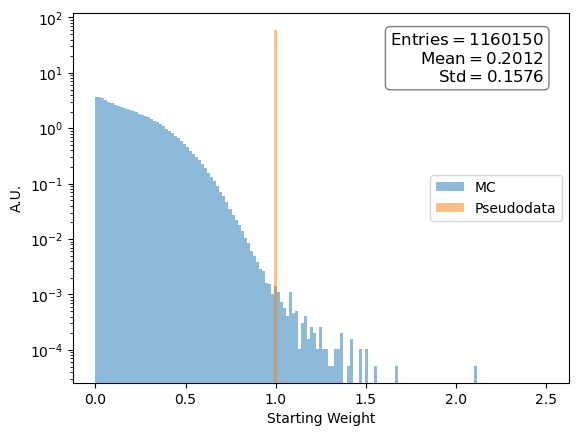

In [12]:
bins = np.linspace(0, 2.5, 150)
plt.hist(mc_weights, bins=bins, alpha=0.5, label='MC', density=True)
plt.hist(pd_weights, bins=bins, alpha=0.5, label='Pseudodata', density=True)
add_stats_box(plt.gca(), mc_weights)
plt.legend(loc='center right')
plt.yscale('log')
plt.xlabel('Starting Weight')
plt.ylabel('A.U.')
plt.show()

In [13]:
class_ratio = np.sum(mc_weights) / np.sum(pd_weights)
print("Class ratio: {}".format(class_ratio))

Class ratio: 0.9892692565917969


Make the labels. We will call pseudodata signal, and MC background.

In [14]:
# Build labels
mc_labels = np.zeros((mc_kinematics.shape[0], 1), dtype=np.float32)
pd_labels = np.ones((pd_kinematics.shape[0], 1), dtype=np.float32)

Concatenate MC and PD together. Since with the weights the class ratio is nearly one, just use all of the events

In [15]:
# Concatenate MC and pseudodata together
kinematics = np.concatenate([mc_kinematics, pd_kinematics], axis=0)
mask = np.concatenate([mc_mask, pd_mask], axis=0)
weights = np.concatenate([mc_weights, pd_weights], axis=0)
labels = np.concatenate([mc_labels, pd_labels], axis=0)

Finally done cleaning data. Make train test split and move data to GPU

In [16]:
# Make train test split
kinematics_train, kinematics_test, labels_train, labels_test, mask_train, mask_test, weights_train, weights_test = train_test_split(kinematics, labels, mask, weights, test_size=0.2, random_state=42)
print(kinematics_train.shape, kinematics_test.shape, labels_train.shape, labels_test.shape, mask_train.shape, mask_test.shape, weights_train.shape, weights_test.shape)

(1116853, 10, 52) (279214, 10, 52) (1116853, 1) (279214, 1) (1116853, 1, 52) (279214, 1, 52) (1116853, 1) (279214, 1)


In [17]:
# Convert to torch tensors
device = 'cuda:0'
kinematics_train = torch.tensor(kinematics_train, dtype=torch.float32).to(device).contiguous()
kinematics_test = torch.tensor(kinematics_test, dtype=torch.float32).to(device).contiguous()
labels_train = torch.tensor(labels_train, dtype=torch.float32).to(device)
labels_test = torch.tensor(labels_test, dtype=torch.float32).to(device)
mask_train = torch.tensor(mask_train, dtype=torch.float32).to(device)
mask_test = torch.tensor(mask_test, dtype=torch.float32).to(device)
weights_train = torch.tensor(weights_train, dtype=torch.float32).to(device)
weights_test = torch.tensor(weights_test, dtype=torch.float32).to(device)

In [18]:
# Build a pytorch dataset
train_dataset = torch.utils.data.TensorDataset(kinematics_train, labels_train, mask_train, weights_train)
test_dataset = torch.utils.data.TensorDataset(kinematics_test, labels_test, mask_test, weights_test)

In [19]:
# Build pytorch data loaders
batch_size = 256
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

In [20]:
print(len(train_loader))

4362


Data is ready. Next we need to build a model!

In [29]:
from of_transformer import OfTransformer
from simple_network import DumbNeuralNetwork
part = OfTransformer(
    10,
    num_classes=1,
    trim=False,
    remove_self_pair=True,
    embed_dims=[256, 256, 128],
    pair_input_dim=3,
    pair_extra_dim=0,
    pair_embed_dims=[32, 64, 128],
    fc_params=[(256, 0.0)],
    cls_block_params={'dropout': 0, 'attn_dropout': 0, 'activation_dropout': 0, 'num_heads': 8},
    num_cls_layers=2,
    block_params={'dropout': 0.1, 'attn_dropout': 0.1, 'activation_dropout': 0.1, 'num_heads': 8},
    num_layers=3
)
# part = DumbNeuralNetwork()
ex_param = next(part.parameters())
print(ex_param)
print(ex_param.shape)

Batch normalization disabled in embeddings!
Parameter containing:
tensor([[[-0.0010,  0.0066,  0.0307, -0.0149, -0.0016,  0.0009,  0.0066,
           0.0116, -0.0129, -0.0159,  0.0364, -0.0112,  0.0341,  0.0051,
           0.0019,  0.0191,  0.0108, -0.0142, -0.0400, -0.0106, -0.0035,
          -0.0033, -0.0267,  0.0058,  0.0236,  0.0292,  0.0082, -0.0002,
           0.0141,  0.0137, -0.0169, -0.0259, -0.0042,  0.0006,  0.0289,
           0.0035, -0.0010,  0.0024, -0.0131,  0.0216, -0.0076,  0.0064,
           0.0132,  0.0157, -0.0076, -0.0024, -0.0147,  0.0164, -0.0155,
          -0.0282,  0.0044, -0.0202,  0.0140, -0.0008,  0.0155,  0.0466,
          -0.0164, -0.0195, -0.0027, -0.0233, -0.0113,  0.0131,  0.0182,
          -0.0320, -0.0257,  0.0197, -0.0055,  0.0006,  0.0207,  0.0263,
          -0.0343,  0.0052, -0.0134,  0.0001,  0.0020,  0.0144, -0.0260,
           0.0151,  0.0335, -0.0290,  0.0165,  0.0128,  0.0061, -0.0079,
           0.0097, -0.0096,  0.0066,  0.0081,  0.0067, -0.

In [30]:
summary(part, input_shape=(10, 256))

Layer (type:depth-idx)                                       Param #
OfTransformer                                                128
├─SequenceTrimmer: 1-1                                       --
├─Embed: 1-2                                                 --
│    └─InputDistributed: 2-1                                 --
│    │    └─Sequential: 3-1                                  101,504
├─PairEmbed: 1-3                                             --
│    └─Sequential: 2-2                                       --
│    │    └─Conv1d: 3-2                                      128
│    │    └─BatchNorm1d: 3-3                                 64
│    │    └─GELU: 3-4                                        --
│    │    └─Conv1d: 3-5                                      2,112
│    │    └─BatchNorm1d: 3-6                                 128
│    │    └─GELU: 3-7                                        --
│    │    └─Conv1d: 3-8                                      8,320
│    │    └─BatchNorm

In [31]:
# Copy model to GPU
part.to('cuda:0')
next(part.parameters()).device

device(type='cuda', index=0)

In [32]:
# Practice forward pass
first_batch = next(iter(train_loader))
first_event = first_batch[0]
first_tracks = first_event[:,:3,:]
first_mask = first_batch[2]
with torch.no_grad():
    out = part(first_event, v=first_tracks)
print(first_event[0,...])
print(out)


tensor([[ 6.2665,  3.9097,  4.0114,  3.8467,  3.8270,  3.7397,  3.1343,  2.8967,
          2.8103,  2.7012,  2.5042,  2.3982,  2.3324,  2.2501,  1.9210,  1.8280,
          1.7949,  1.6617,  1.5525,  1.3066,  1.3001,  1.1840,  1.1782,  1.1716,
          1.1510,  1.0994,  1.0929,  0.9942,  0.8940,  0.8033,  0.7100,  0.7089,
          0.6687,  0.5416,  0.4702,  0.4304,  0.4236,  0.4186,  0.3684,  0.3172,
          0.2280,  0.1900,  0.0471,  0.0359,  0.0196,  0.0153, -0.0160, -0.0463,
         -0.0671, -0.0693, -0.0790, -0.0895],
        [ 1.4085,  1.9304,  1.2433,  0.1622,  1.2512,  0.1478,  1.2455,  0.1637,
          0.1695,  0.1888,  1.2679,  1.7566,  0.1822,  0.1586,  1.2349,  0.1186,
          0.1079,  1.1939,  1.2659,  1.1999, -0.3125,  2.4545, -0.4726,  1.7381,
          1.0873, -0.2216, -2.3089,  2.2523,  1.3901, -1.9906, -1.2001,  1.6808,
          0.2422,  0.9260,  1.6978, -0.2624, -1.1324,  0.0092,  0.4646,  1.2673,
         -0.3304, -1.4553, -0.5417,  1.4296,  1.5952,  0.5655, 

/global/homes/k/kgreif/.conda/envs/zjets/lib/python3.11/site-packages/torch/nn/functional.py:5076: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Now train the model. Define and optimizer and a loss function

In [33]:
criterion = torch.nn.BCEWithLogitsLoss(reduction='none')
optimizer = torch.optim.Adam(part.parameters(), lr=1e-4)

And train for a few epochs

In [34]:
epochs = int(10)
part.train()

for epoch in range(epochs):  # loop over the dataset multiple times

    print("Epoch {}".format(epoch + 1))
    loop_obj = tqdm(enumerate(train_loader), total=len(train_loader))

    running_loss = 0.0
    for i, batch in loop_obj:

        # Unpack batch 
        batch_kinematics, batch_labels, batch_mask, batch_weights = batch
        batch_tracks = batch_kinematics[:,:3,:]

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass, compute loss, backward pass, optimizer step
        out = part(batch_kinematics, v=batch_tracks, mask=batch_mask)
        loss = criterion(out, batch_labels)
        loss = loss * batch_weights
        loss.mean().backward()
        optimizer.step()

        # Print stats
        running_loss += loss.mean().item()
        if i % 100 == 99:    # print every 100 mini-batches
            # print(f'Epoch {epoch + 1}, mini-batch {i + 1}: loss {running_loss / 100:.3f}')
            loop_obj.set_postfix({'loss': running_loss / 100})
            running_loss = 0.0


Epoch 1


  0%|          | 0/4362 [00:00<?, ?it/s]

Epoch 2


  0%|          | 0/4362 [00:00<?, ?it/s]

Epoch 3


...

Epoch 4


  0%|          | 0/4362 [00:00<?, ?it/s]

Epoch 5


  0%|          | 0/4362 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [35]:
import itertools

# Print results on first batch
first_batch = next(itertools.islice(iter(train_loader), 0, None))
first_event = first_batch[0]
first_mask = first_batch[2]
first_labels = first_batch[1]
sig = torch.nn.Sigmoid()

part.eval()
with torch.no_grad():
    out = part(first_event)
print(first_event[0,...])
print(sig(out[:10]).detach().cpu().numpy().flatten())
print(first_labels[:10])


tensor([[ 5.3900,  4.5377,  2.6192,  2.4746,  2.1246,  2.0469,  1.8630,  1.8491,
          1.7647,  1.7264,  1.6890,  1.5494,  1.3681,  1.2669,  1.2551,  1.2390,
          1.2286,  1.0549,  0.9452,  0.9430,  0.8963,  0.8698,  0.8679,  0.8025,
          0.6989,  0.5825,  0.5741,  0.5050,  0.4878,  0.4767,  0.4748,  0.4169,
          0.3656,  0.3183,  0.3068,  0.2684,  0.1689,  0.1472,  0.1285,  0.1118,
          0.0861,  0.0526,  0.0522,  0.0281, -0.0392, -0.0435, -0.0517, -0.0594,
         -0.0805, -0.0867, -0.0868, -0.0872],
        [-1.9235, -1.4122, -1.5189, -1.4743,  2.2687, -1.5074, -1.2330,  0.8858,
         -1.5512,  2.3890, -1.5341,  2.3650,  2.3120, -1.5101, -0.2311,  2.2247,
          1.7710,  2.4812, -1.2000, -2.1622,  2.3113, -1.4863, -2.1807,  2.2077,
          0.8377, -0.4729,  2.3232,  2.3080,  2.3902, -1.5464,  2.4598, -1.2657,
         -1.2186,  0.7143, -2.0740, -1.0140, -0.4725, -1.7114,  2.1695,  0.8926,
         -1.8990, -1.8926, -2.2859,  1.5209, -2.1796, -0.0759, 

Now we need to determine whether there is a reasonable weighting derived by this network. Run prediction over testing set and plot the reweighting

In [36]:
# Run prediction over the test dataloader
part.eval()
with torch.no_grad():
    predictions = []
    for batch in tqdm(test_loader):
        batch_kinematics, batch_labels, batch_mask, batch_weights = batch
        out = part(batch_kinematics, mask=batch_mask)
        predictions.append(out.detach().cpu().numpy().flatten())
    predictions = np.concatenate(predictions)
    probs = 1 / (1 + np.exp(-predictions))
    derived_weights = probs / (1 - probs)

  0%|          | 0/1091 [00:00<?, ?it/s]

In [37]:
# Plot the quality of the reweighting
test_dataset = test_loader.dataset
test_events = test_dataset[:][0].detach().cpu().numpy()
test_weights = test_dataset[:][3].detach().cpu().numpy().flatten()

# Extract muon kinematics
alldata = {}
alldata['m1_pt'] = np.exp(test_events[:, 0, 0])
alldata['m2_pt'] = np.exp(test_events[:, 0, 1])
alldata['m1_eta'] = test_events[:, 1, 0]
alldata['m2_eta'] = test_events[:, 1, 1]
alldata['m1_phi'] = test_events[:, 2, 0]
alldata['m2_phi'] = test_events[:, 2, 1]
alldata['end_weights'] = test_weights * derived_weights
alldata['start_weights'] = test_weights
v1 = np.stack([alldata['m1_pt'] * np.cos(alldata['m1_phi']), alldata['m1_pt'] * np.sin(alldata['m1_phi']), alldata['m1_pt'] * np.sinh(alldata['m1_eta'])], axis=1)
v2 = np.stack([alldata['m2_pt'] * np.cos(alldata['m2_phi']), alldata['m2_pt'] * np.sin(alldata['m2_phi']), alldata['m2_pt'] * np.sinh(alldata['m2_eta'])], axis=1)
vall = v1 + v2
print(v1.shape)
print(vall.shape)
print(vall[:10,:])
alldata['mm_pt'] = np.sqrt(vall[:,0]**2 + vall[:,1]**2)

# Extract labels
labels = test_dataset[:][1].detach().cpu().numpy().flatten()

# Separate MC and pseudodata
mc_data = {key: val[labels == 0] for key, val in alldata.items()}
pd_data = {key: val[labels == 1] for key, val in alldata.items()}

(279214, 3)
(279214, 3)
[[ 472.52002   -78.273186  897.4651  ]
 [-288.03983  -220.45169   194.8722  ]
 [  95.574554 -191.78568  -971.78235 ]
 [ -40.520706  232.8585     75.3334  ]
 [  44.041485 -186.60939   -85.91742 ]
 [-141.43462   132.12157   215.82939 ]
 [ 104.74833  -208.5203     22.381243]
 [-441.75726   148.95332   247.39444 ]
 [-191.4534    -75.45083  -163.70566 ]
 [-203.16287   164.01126   575.87537 ]]


In [38]:
print(np.mean(mc_data['start_weights']))
print(np.mean(mc_data['end_weights']))
print(np.mean(pd_data['start_weights']))
print(np.mean(pd_data['end_weights']))

0.20163083
0.047190573
1.0
0.36857244


/global/u2/k/kgreif/zjets/of_transformer/plotting_utils.py:484: RuntimeWarning: divide by zero encountered in divide
  axr.plot(bins[:-1], n_mc / n_pd, color='#1f77b4', drawstyle='steps-post')
/global/u2/k/kgreif/zjets/of_transformer/plotting_utils.py:484: RuntimeWarning: invalid value encountered in divide
  axr.plot(bins[:-1], n_mc / n_pd, color='#1f77b4', drawstyle='steps-post')
/global/u2/k/kgreif/zjets/of_transformer/plotting_utils.py:485: RuntimeWarning: divide by zero encountered in divide
  axr.plot(bins[:-1], n_rw / n_pd, color='k', drawstyle='steps-post')
/global/u2/k/kgreif/zjets/of_transformer/plotting_utils.py:485: RuntimeWarning: invalid value encountered in divide
  axr.plot(bins[:-1], n_rw / n_pd, color='k', drawstyle='steps-post')


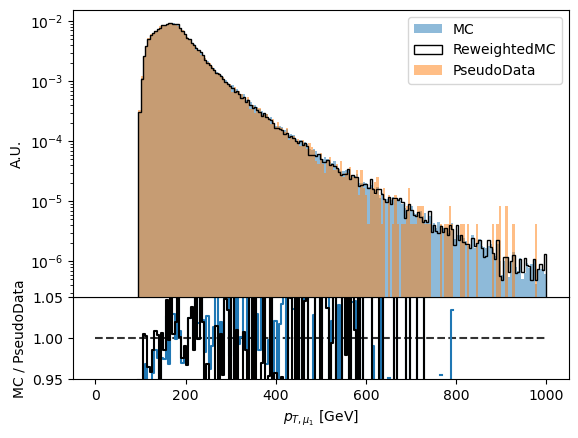

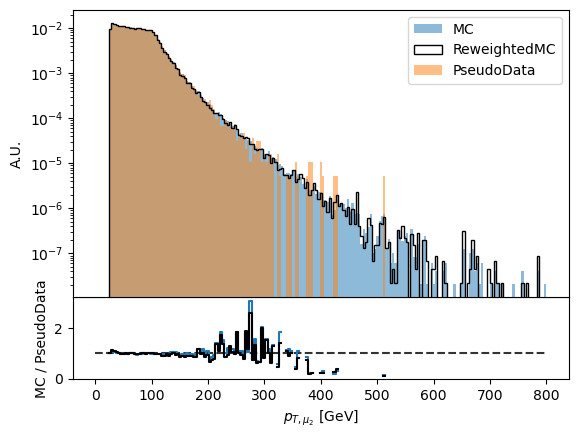

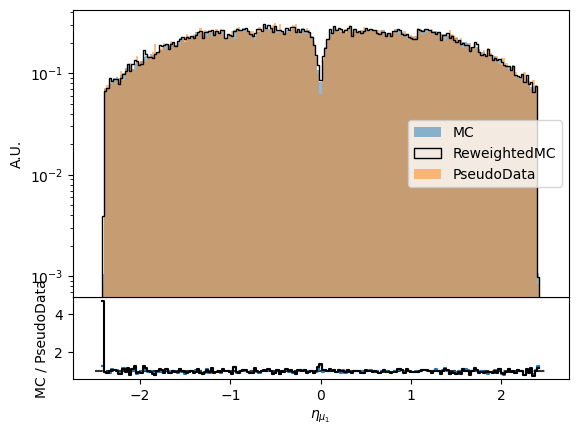

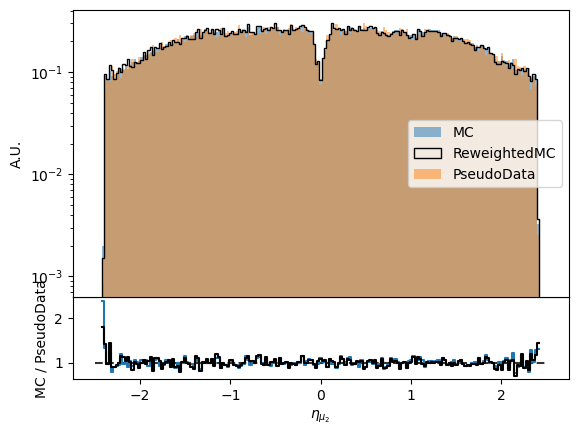

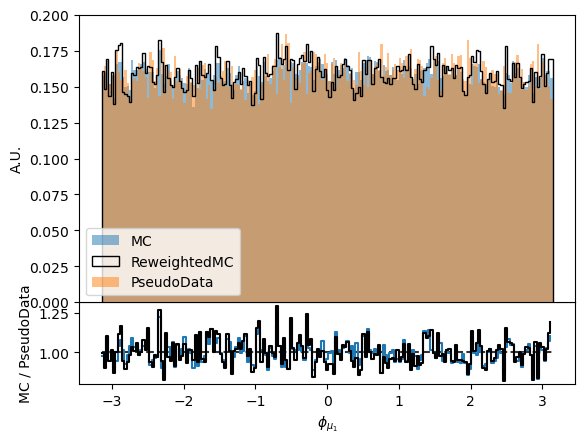

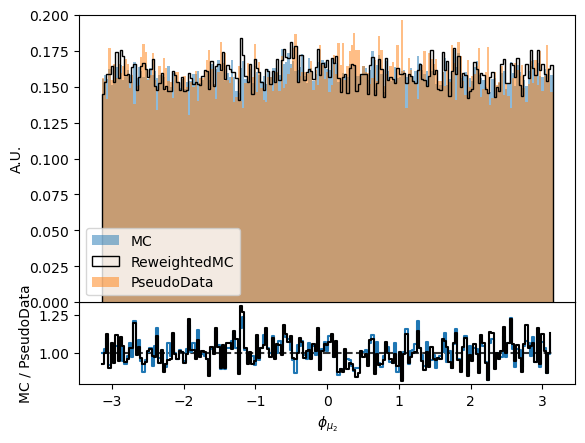

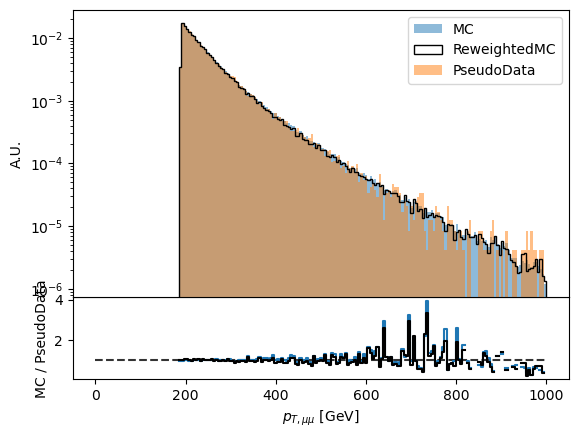

In [39]:
from plotting_utils import *
fig = plot_reweighting(mc_data['m1_pt'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m1_pt'], bins=np.linspace(0, 1e3, 200), xlabel=r'$p_{T, \mu_1}$ [GeV]', rlim=[0.95, 1.05])
fig.show()
fig = plot_reweighting(mc_data['m2_pt'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m2_pt'], bins=np.linspace(0, 800, 200), xlabel=r'$p_{T, \mu_2}$ [GeV]')
fig.show()
fig = plot_reweighting(mc_data['m1_eta'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m1_eta'], bins=np.linspace(-2.5, 2.5, 200), xlabel=r'$\eta_{\mu_1}$')
fig.show()
fig = plot_reweighting(mc_data['m2_eta'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m2_eta'], bins=np.linspace(-2.5, 2.5, 200), xlabel=r'$\eta_{\mu_2}$')
fig.show()
fig = plot_reweighting(mc_data['m1_phi'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m1_phi'], bins=np.linspace(-np.pi, np.pi, 200), xlabel=r'$\phi_{\mu_1}$', linear_scale=True, ylim=[0, 0.2])
fig.show()
fig = plot_reweighting(mc_data['m2_phi'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m2_phi'], bins=np.linspace(-np.pi, np.pi, 200), xlabel=r'$\phi_{\mu_2}$', linear_scale=True, ylim=[0, 0.2])
fig.show()
fig = plot_reweighting(mc_data['mm_pt'], mc_data['start_weights'], mc_data['end_weights'], pd_data['mm_pt'], bins=np.linspace(0, 1e3, 200), xlabel=r'$p_{T, \mu\mu}$ [GeV]')
fig.show()

Lovely. We're getting all 6 dimensions plus one derived dimension with acceptable precision for now. This is great. Let's try training and evaluating something like this in production mode, and logging these plots during training. That way I can look for any overfitting effects.